In [4]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import sys
from pathlib import Path

# Add the project root (ml_laboratory) to Python's search path
sys.path.append(str(Path().resolve().parent))
from sklearn.preprocessing import (
StandardScaler, OneHotEncoder
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (
    LinearRegression,
    Ridge, Lasso, ElasticNet
)
from sklearn.metrics import (
mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
)
import time

# Using the EDA functions from assignment 1
from utils import (
    eda_images,eda_tabular
)
print("Imported successfully")

Imported successfully
Imported successfully


Shape: (592, 12)

Column types:
 Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Missing values:
 Gender               13
Married               2
Dependents           13
Education             0
Self_Employed        31
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

Duplicate rows: 0

Summary statistics:
        ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       592.000000         592.000000  592.000000        578.000000   
mean       5404.304054        1642.633311  146.412162        342.145329   
std        6164.0730

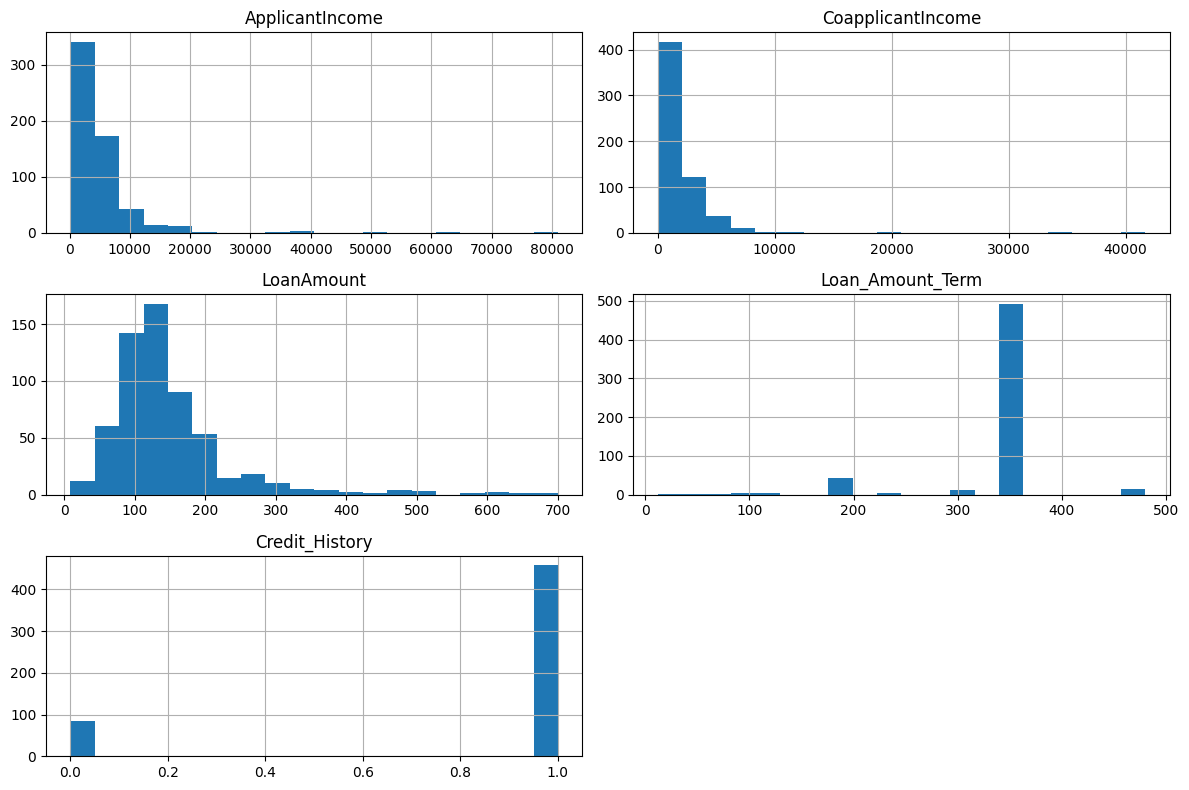

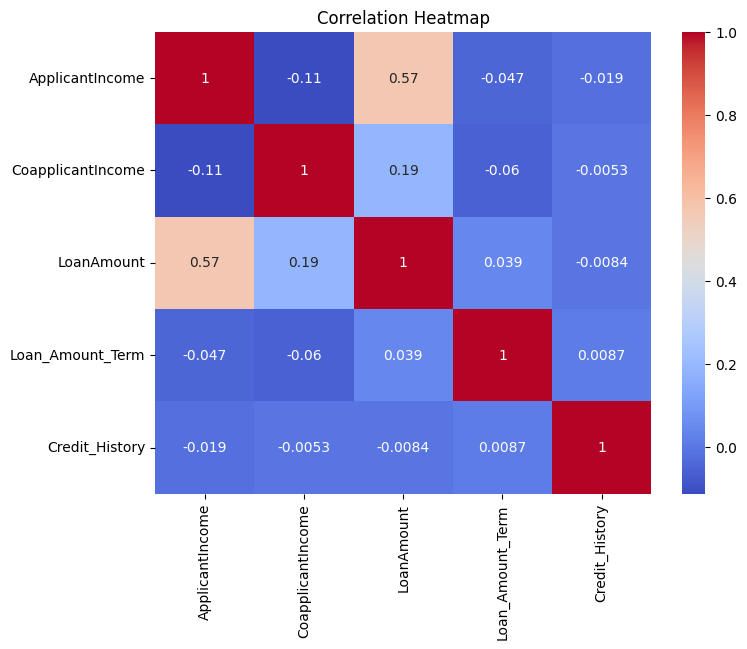

(Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
        'Loan_Amount_Term', 'Credit_History'],
       dtype='str'),
 Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
        'Property_Area', 'Loan_Status'],
       dtype='str'))

In [6]:
df = pd.read_csv("../datasets/loan_prediction/train.csv")
df.drop("Loan_ID",axis = 1,inplace =True)
df = df.dropna(subset=["LoanAmount"])
eda_tabular(df)

In [24]:

X = df.drop(['LoanAmount'], axis = 1)
y = df['LoanAmount']

numerical_cols = X.select_dtypes(include=["int64","float64"]).columns
categorical_cols = X.select_dtypes(include=["object","category","str"]).columns

print("Numerical columns are: ",numerical_cols)
print("Categorical columns are: ",categorical_cols)


Numerical columns are:  Index(['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term',
       'Credit_History'],
      dtype='str')
Categorical columns are:  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='str')


In [25]:
# Missing value handling
numeric_transform = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transform = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [26]:
# Encoding and standardization
preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_transform,numerical_cols),
        ("cat",categorical_transform,categorical_cols)
    ]
)

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Preprocessing
X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)
print(X_train.shape)
print(X_test.shape)

(473, 21)
(119, 21)


In [28]:
def actual_vs_pred(y_test, y_pred, name = None):
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Loan Amount")
    plt.ylabel("Predicted Loan Amount")
    if name == None:
        plt.title("Actual vs Predicted values")
    else:
        plt.title(f"Actual vs Predicted values of model {name}")
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )

def residual_plot(y_test, y_pred, name = None):
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, color = 'red', linestyle = '--')
    plt.xlabel("predicted")
    plt.ylabel("Residual")
    if name == None:
        plt.title("Residual Plot")
    else:
        plt.title(f"Residual plot of model {name}")

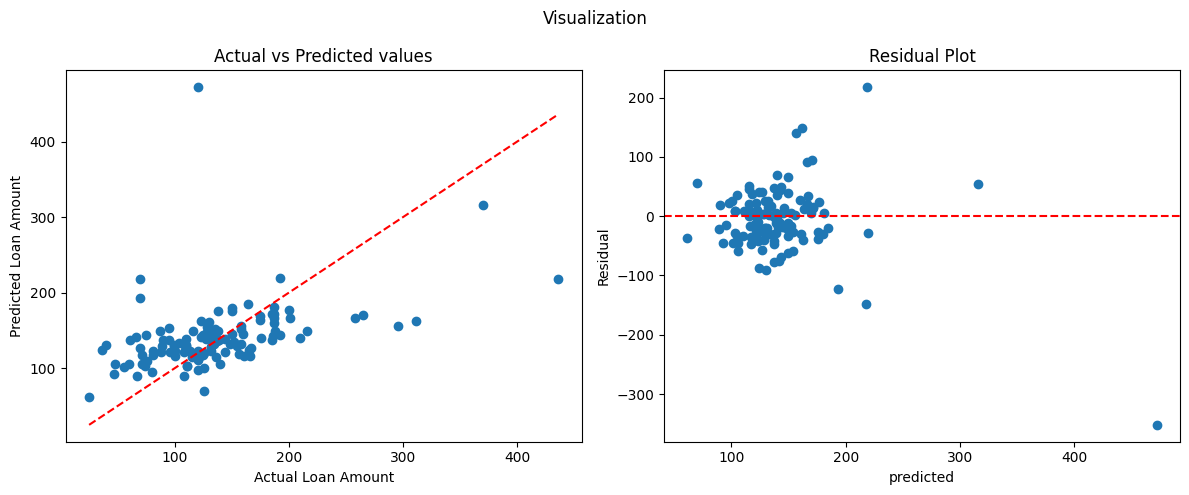

In [29]:
# Now using train and test dataset apply Linear Regression
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet()
}
model = LinearRegression()
model.fit(X_train,y_train)

# Making predictions
y_pred = model.predict(X_test)
plt.figure(figsize = (12,5))
plt.suptitle(f"Visualization")
plt.subplot(1,2,1)
actual_vs_pred(y_test,y_pred)
plt.subplot(1,2,2)
residual_plot(y_test, y_pred)
plt.tight_layout()
plt.show()

# Performance Metrics
|  Regression  |   Classification  |
|--------------|-------------------|
| Mean Absolute Error        |    Accuracy       |
| Mean Squared error          |   Precision     |
| Root mean squared error    |  Recall   |
| $R^2$ error |  f1 score |

Since this is regression model we have to use MAE, MSE, RMSE, R2 error

In [30]:

from sklearn.model_selection import cross_val_score

for func in models:
    print(f"\n======= {func} =======")
    models[func].fit(X_train,y_train)
    
    # Making predictions
    y_pred = models[func].predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("MAE = %.3f"%(mae))
    print("MSE = %.3f"%(mse))
    print("RMSE = %.3f"%(rmse))
    print("R2 score = %.3f" %(r2))

    # Cross validation

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", models[func])
    ])
    
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="r2"
    )
    print("\nCross Validation Scores: ",scores)
    print("Average R^2 : %.2f" %(scores.mean()))

    # Bias variance tradeoff
    print("Train R2 :", models[func].score(X_train,y_train))
    print("Test R2 :", models[func].score(X_test,y_test))
    


======= Linear Regression =======
MAE = 36.988
MSE = 3339.922
RMSE = 57.792
R2 score = 0.094

Cross Validation Scores:  [ 0.58020963  0.41602553  0.50360729 -0.58936696  0.27472472]
Average R^2 : 0.24
Train R2 : 0.45667871824083417
Test R2 : 0.09398318319031951

======= Ridge =======
MAE = 36.971
MSE = 3334.977
RMSE = 57.749
R2 score = 0.095

Cross Validation Scores:  [ 0.5794855   0.41639629  0.5034068  -0.5834376   0.27574268]
Average R^2 : 0.24
Train R2 : 0.45667564698418883
Test R2 : 0.09532443586719341

======= Lasso =======
MAE = 35.841
MSE = 3232.042
RMSE = 56.851
R2 score = 0.123

Cross Validation Scores:  [ 0.56223069  0.44293651  0.50427677 -0.52844624  0.29155762]
Average R^2 : 0.25
Train R2 : 0.45123393397474365
Test R2 : 0.12324753320082793

======= ElasticNet =======
MAE = 37.826
MSE = 3048.685
RMSE = 55.215
R2 score = 0.173

Cross Validation Scores:  [0.41348879 0.36352907 0.40321368 0.05118821 0.26911697]
Average R^2 : 0.30
Train R2 : 0.3928752603383602
Test R2 : 0.172

In [ ]:

from sklearn.model_selection import GridSearchCV

models = {
    "Linear Regression": (
        LinearRegression(),
        {}
    ),
    
    "Ridge Regression": (
        Ridge(),
        {
            "alpha":[0.001,0.01,0.1,1,10,100]
        }
    ),
    
    "Lasso Regression": (
        Lasso(),
        {
            "alpha":[0.001,0.01,0.1,1,10,100]
        }
    ),
    
    "ElasticNet "
    "Regression": (
        ElasticNet(max_iter=10000),
        {
            "alpha":[0.001,0.01,0.1,1,10,100],
            "l1_ratio":[0.1,0.3,0.5,0.7,0.9]
        }
    )
}

for name, (model, params) in models.items():

    print(f"\n{name}")

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)

    print("Best Parameters :", grid.best_params_)
    print("Best CV Score   :", grid.best_score_)


Linear Regression
Best Parameters : {}
Best CV Score   : 0.18402531464249766

Ridge Regression


Best Parameters : {'alpha': 100}
Best CV Score   : 0.3406664168081769

Lasso Regression
Best Parameters : {'alpha': 10}
Best CV Score   : 0.2544201600239591

ElasticNet Regression
Best Parameters : {'alpha': 1, 'l1_ratio': 0.7}
Best CV Score   : 0.34077198822391347


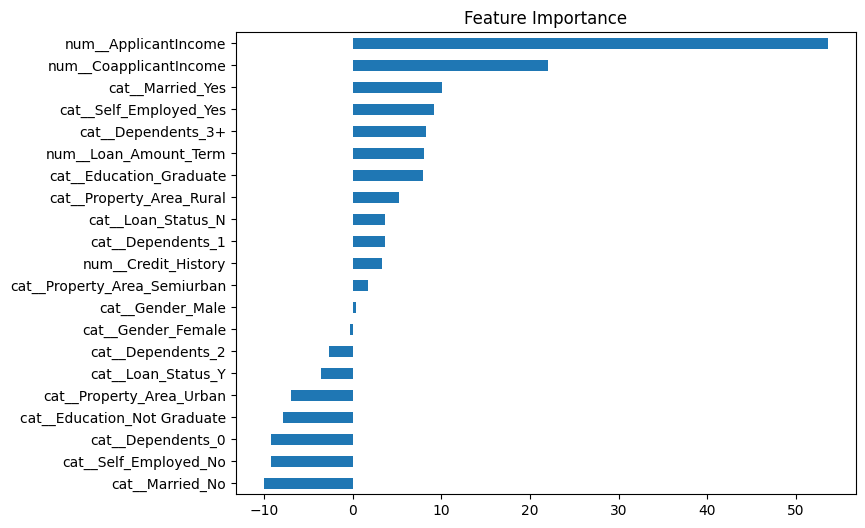

In [33]:
model = Ridge()
model.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()
coef = pd.Series(model.coef_, index=feature_names)

coef.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()